In [4]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from wordcloud import WordCloud


nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
# ===============================
# 2. LOAD DATASET
# ===============================
df = pd.read_csv("twcs.csv")  # Twitter dataset

# Keep only customer messages
df = df[df['inbound'] == True]

# Keep only relevant columns
df = df[['text']].dropna()

df = df.sample(50000)  # reduce size for performance

In [6]:
# ===============================
# 3. TEXT CLEANING
# ===============================
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)   # remove links
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text

df['cleaned'] = df['text'].apply(clean_text)

# ===============================
# 4. REMOVE STOPWORDS
# ===============================
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

df['processed'] = df['cleaned'].apply(remove_stopwords)


In [7]:
# ===============================
# 5. CREATE SENTIMENT LABELS
# ===============================
# Simple rule-based labeling (for demo)

def label_sentiment(text):
    negative_words = ['not', 'no', 'delay', 'bad', 'worst', 'issue', 'problem', 'complaint']

    if any(word in text for word in negative_words):
        return "negative"
    else:
        return "positive"

df['sentiment'] = df['processed'].apply(label_sentiment)

In [8]:
# ===============================
# 6. FEATURE EXTRACTION (TF-IDF)
# ===============================
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['processed'])
y = df['sentiment']

# ===============================
# 7. TRAIN TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ===============================
# 8. MODEL TRAINING
# ===============================
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [9]:
# ===============================
# 9. EVALUATION
# ===============================
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ===============================
# 10. CHURN RISK CREATION
# ===============================
def churn_risk(sentiment):
    if sentiment == "negative":
        return "High Risk"
    else:
        return "Low Risk"

df['churn_risk'] = df['sentiment'].apply(churn_risk)

Accuracy: 0.9589
              precision    recall  f1-score   support

    negative       1.00      0.79      0.88      1935
    positive       0.95      1.00      0.98      8065

    accuracy                           0.96     10000
   macro avg       0.98      0.89      0.93     10000
weighted avg       0.96      0.96      0.96     10000



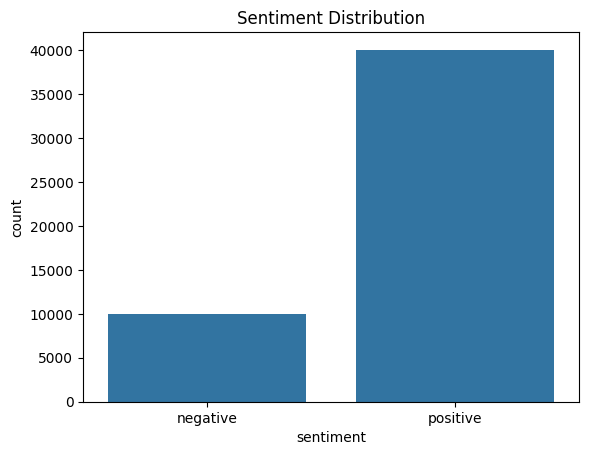

In [10]:
# ===============================
# 11. VISUALIZATION
# ===============================
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()


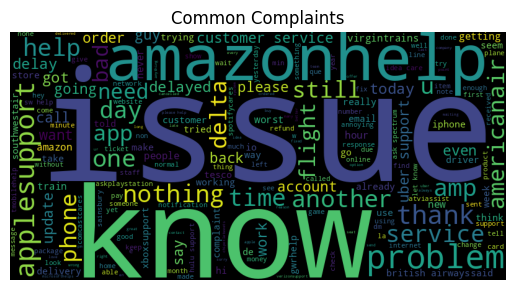

In [11]:
# ===============================
# 12. WORD CLOUD
# ===============================
negative_text = " ".join(df[df['sentiment'] == "negative"]['processed'])

wordcloud = WordCloud(width=800, height=400).generate(negative_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Common Complaints")
plt.show()